In [126]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# funding: floor jittered timestamps to hour, then resample to 8h to align with prices
funding_raw = pd.read_parquet('../data/funding_rates.parquet')
funding_raw.index = funding_raw.index.floor('h')
funding_raw = funding_raw[~funding_raw.index.duplicated(keep='last')]
funding = funding_raw.resample('8h').mean()  # sum hourly rates to get 8h funding
funding = funding.loc[:, ~funding.iloc[0].isna()]

prices = pd.read_parquet('../data/prices.parquet')
prices = prices.loc[:, ~prices.iloc[0].isna()]
universe = pd.read_parquet('../data/universe.parquet')

common_idx = funding.index.intersection(prices.index)
funding = funding.loc[common_idx]
prices  = prices.loc[common_idx]

print(f'Coins:   {len(funding.columns)}')
print(f'Periods: {len(funding)} (8h each)')
print(f'Range:   {funding.index[0].date()} \u2192 {funding.index[-1].date()}')

Coins:   15
Periods: 2191 (8h each)
Range:   2024-04-29 → 2026-04-29


## 1. Universe

In [127]:
display(
    universe[['dayNtlVlm', 'openInterest', 'funding', 'markPx']]
    .rename(columns={'dayNtlVlm': '24h Vol ($)', 'openInterest': 'OI', 'funding': 'Current 8h Funding', 'markPx': 'Mark Price'})
    .sort_values('24h Vol ($)', ascending=False)
    .style.format({'24h Vol ($)': '${:,.0f}', 'OI': '{:,.2f}', 'Current 8h Funding': '{:.4%}', 'Mark Price': '${:,.4f}'})
)

,24h Vol ($),OI,Current 8h Funding,Mark Price
BTC,"$1,917,285,521","27,654.21",-0.0010%,"$76,735.0000"
ETH,"$692,778,463","470,536.86",0.0011%,"$2,300.6000"
HYPE,"$205,608,456","19,516,181.28",0.0013%,$39.7340
SOL,"$163,929,723","2,949,929.02",-0.0009%,$83.9560
DOGE,"$80,366,103","633,410,002.00",0.0013%,$0.1062
PUMP,"$76,746,404","20,271,869,558.00",-0.0038%,$0.0018
ZEC,"$38,799,560","310,763.34",0.0013%,$328.8100
FARTCOIN,"$28,859,380","217,684,376.80",0.0013%,$0.2049
PENGU,"$22,467,140","1,624,355,336.00",-0.0005%,$0.0099
XRP,"$21,938,625","55,753,592.00",-0.0001%,$1.3742


## 2. Funding Rate Distributions

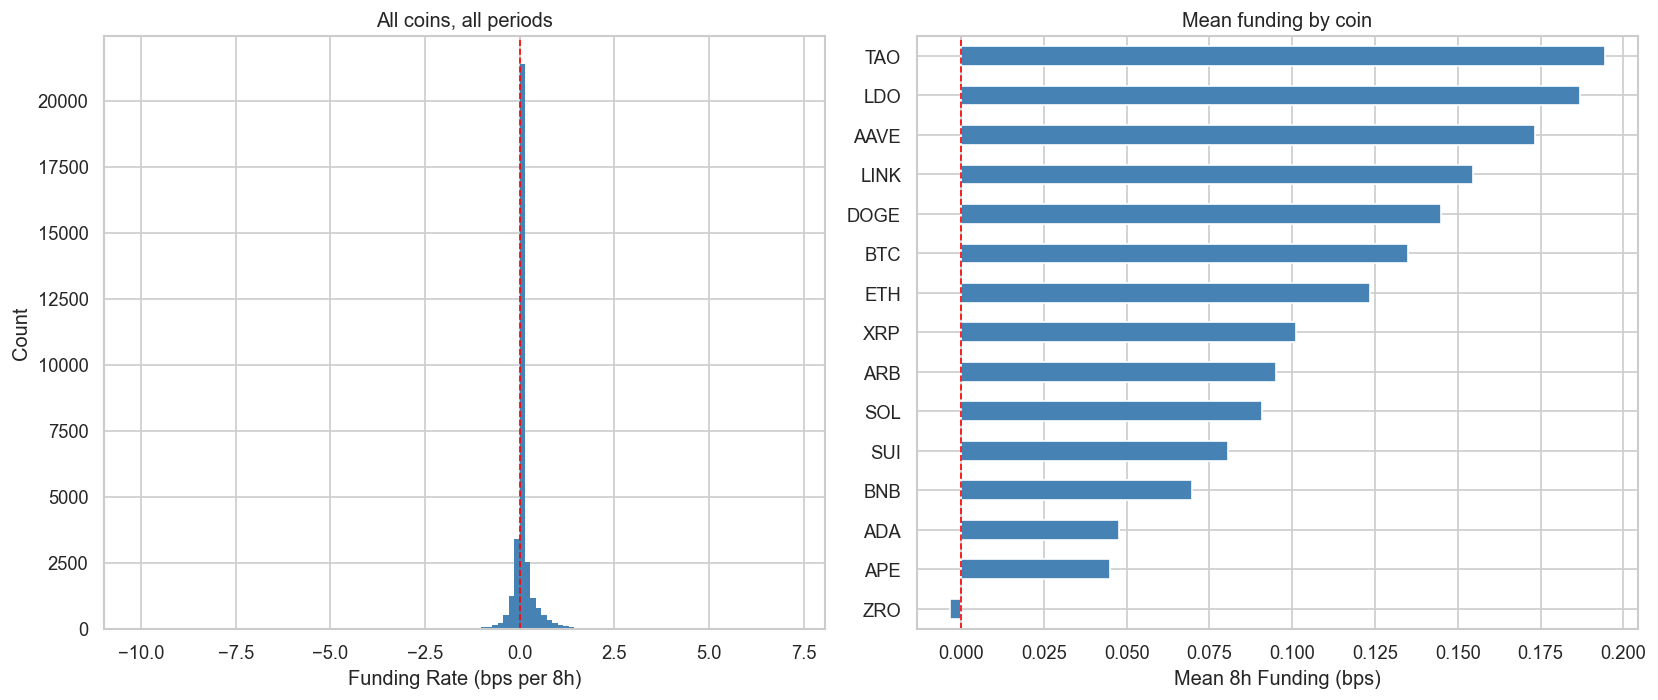

Summary (bps per 8h):
count    32865.000
mean         0.109
std          0.294
min        -10.102
25%          0.056
50%          0.125
75%          0.125
max          7.207


In [128]:
flat = funding.stack().rename('rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(flat * 1e4, bins=120, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', lw=1, ls='--')
axes[0].set_xlabel('Funding Rate (bps per 8h)')
axes[0].set_ylabel('Count')
axes[0].set_title('All coins, all periods')

per_coin_mean = funding.mean() * 1e4
per_coin_mean.sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', lw=1, ls='--')
axes[1].set_xlabel('Mean 8h Funding (bps)')
axes[1].set_title('Mean funding by coin')

plt.tight_layout()
plt.show()

print('Summary (bps per 8h):')
print((flat * 1e4).describe().round(3).to_string())

## 3. Funding Rate Time Series

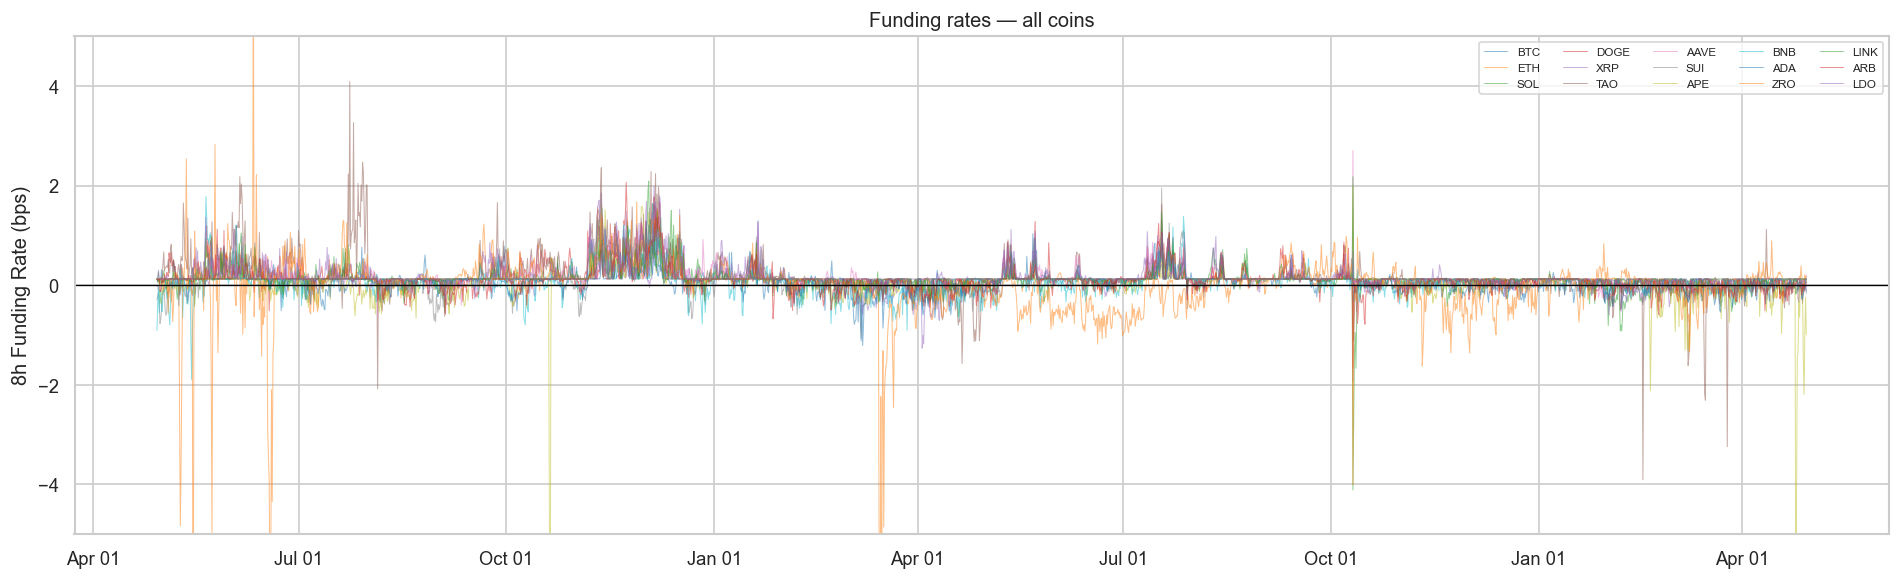

In [129]:
fig, ax = plt.subplots(figsize=(16, 5))
for col in funding.columns:
    ax.plot(funding.index, funding[col] * 1e4, lw=0.6, alpha=0.5, label=col)
ax.axhline(0, color='black', lw=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_ylabel('8h Funding Rate (bps)')
ax.set_title('Funding rates \u2014 all coins')
ax.set_ylim(-5, 5)
ax.legend(ncol=5, fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

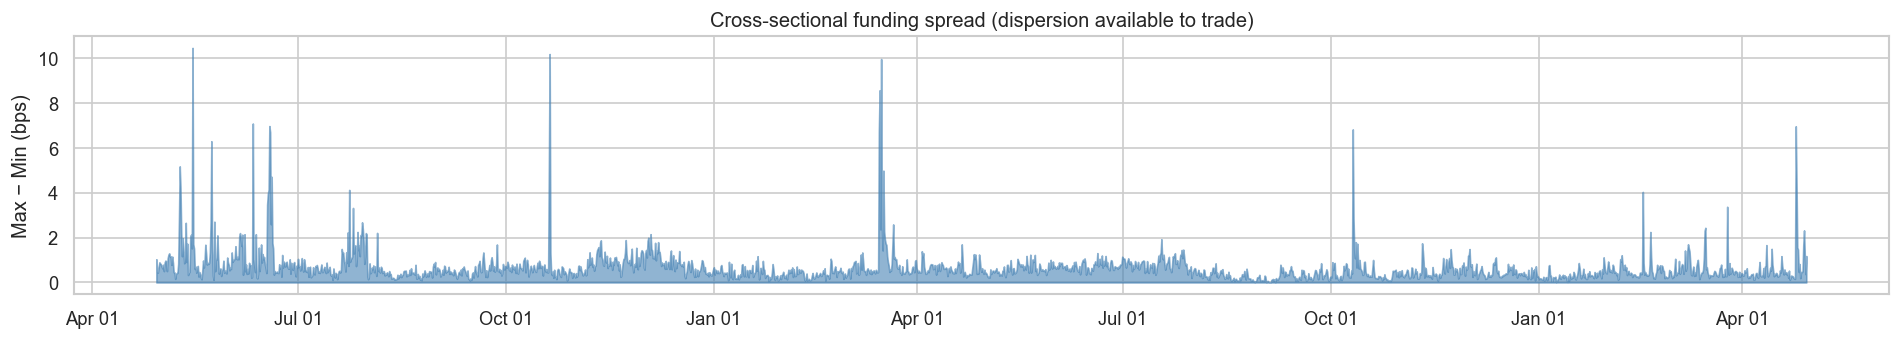

Median spread: 0.51 bps   |   Mean: 0.65 bps   |   p95: 1.46 bps


In [130]:
spread = (funding.max(axis=1) - funding.min(axis=1)) * 1e4

fig, ax = plt.subplots(figsize=(16, 3))
ax.fill_between(spread.index, spread, alpha=0.6, color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_ylabel('Max \u2212 Min (bps)')
ax.set_title('Cross-sectional funding spread (dispersion available to trade)')
plt.tight_layout()
plt.show()

print(f'Median spread: {spread.median():.2f} bps   |   Mean: {spread.mean():.2f} bps   |   p95: {spread.quantile(.95):.2f} bps')

## 4. Autocorrelation -- Does Funding Persist?

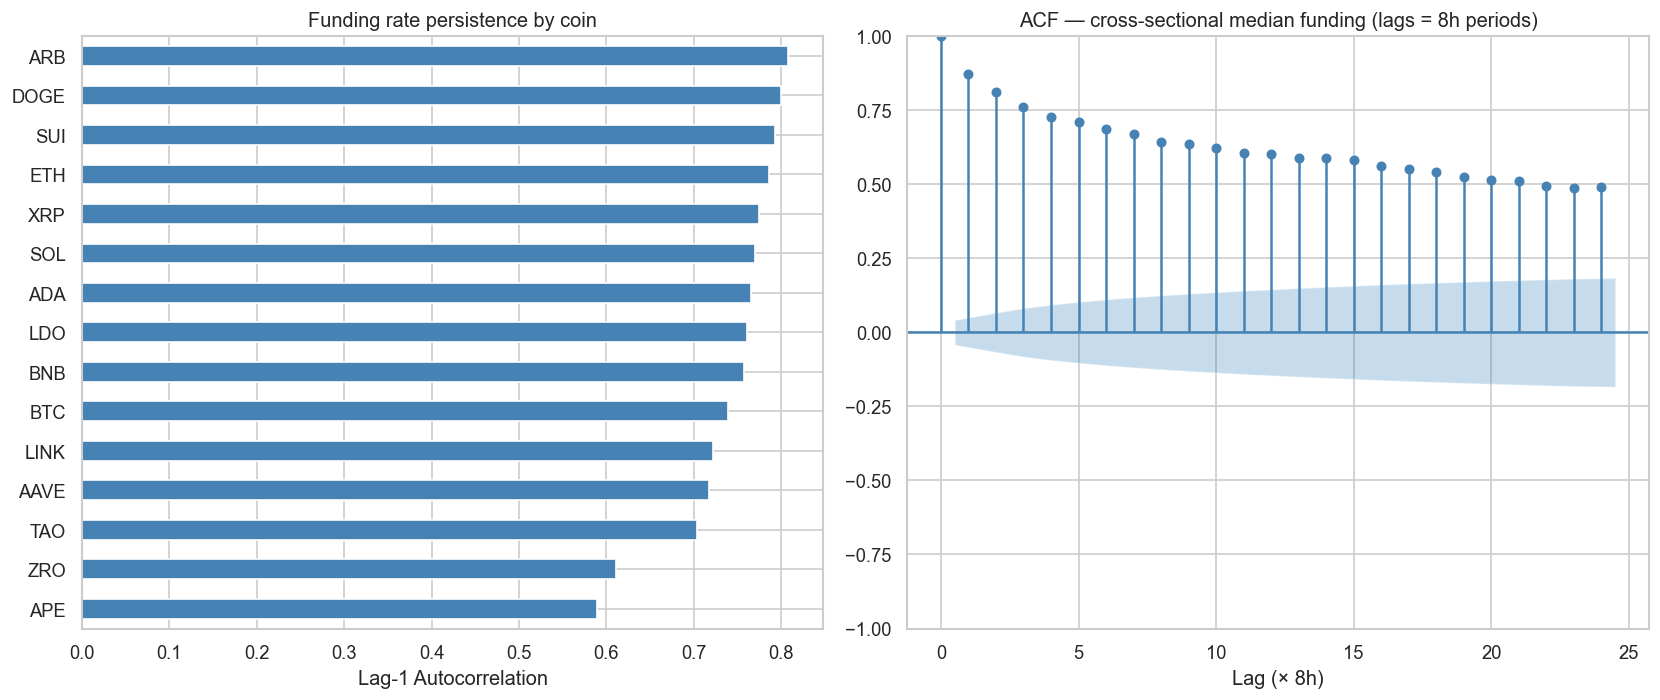

Median lag-1 AC across coins: 0.761
Coins with AC1 > 0.1:  15/15
Coins with AC1 > 0.3:  15/15


In [131]:
ac1 = funding.apply(lambda s: s.autocorr(lag=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ac1.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', lw=1, ls='--')
axes[0].set_xlabel('Lag-1 Autocorrelation')
axes[0].set_title('Funding rate persistence by coin')

median_funding = funding.median(axis=1)
plot_acf(median_funding.dropna(), lags=24, ax=axes[1], color='steelblue', vlines_kwargs={'colors': 'steelblue'})
axes[1].set_title('ACF \u2014 cross-sectional median funding (lags = 8h periods)')
axes[1].set_xlabel('Lag (\u00d7 8h)')

plt.tight_layout()
plt.show()

print(f'Median lag-1 AC across coins: {ac1.median():.3f}')
print(f'Coins with AC1 > 0.1:  {(ac1 > 0.1).sum()}/{len(ac1)}')
print(f'Coins with AC1 > 0.3:  {(ac1 > 0.3).sum()}/{len(ac1)}')

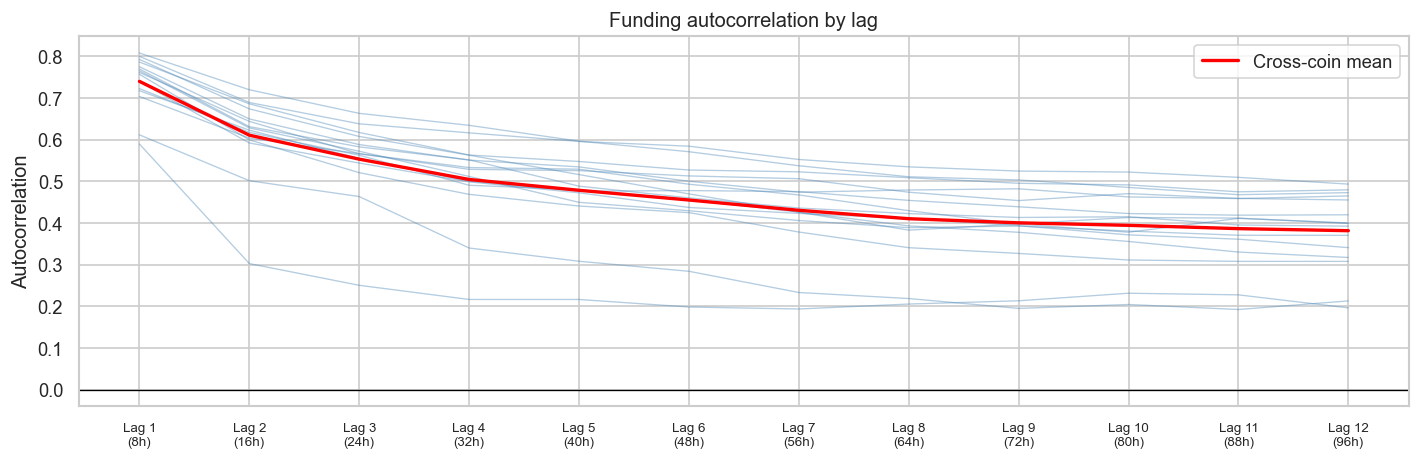

In [132]:
lags = range(1, 13)
ac_matrix = pd.DataFrame(
    {lag: funding.apply(lambda s: s.autocorr(lag=lag)) for lag in lags}
)

fig, ax = plt.subplots(figsize=(12, 4))
for coin in ac_matrix.index:
    ax.plot(list(lags), ac_matrix.loc[coin], lw=0.8, alpha=0.4, color='steelblue')
ax.plot(list(lags), ac_matrix.mean(), color='red', lw=2, label='Cross-coin mean')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(list(lags))
ax.set_xticklabels([f'Lag {l}\n({l*8}h)' for l in lags], fontsize=8)
ax.set_ylabel('Autocorrelation')
ax.set_title('Funding autocorrelation by lag')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Ranking Persistence -- Do High-Funding Coins Stay High?

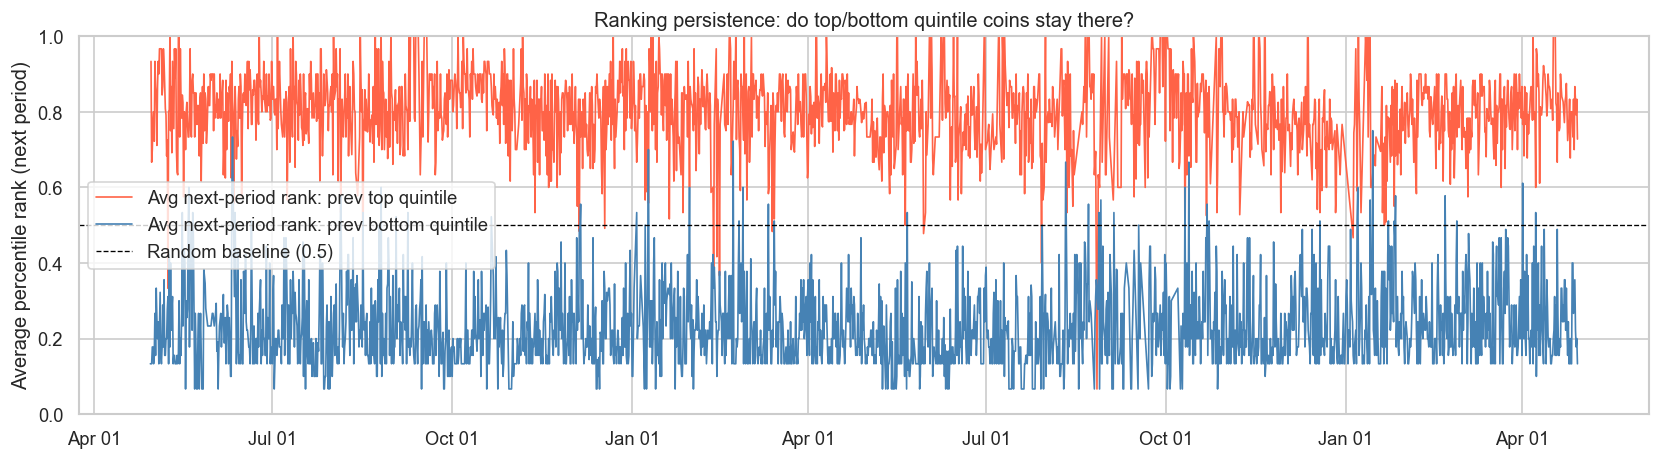

Top quintile avg next-period rank: 0.805  (random = 0.5, persistent = 1.0)
Bot quintile avg next-period rank: 0.230  (random = 0.5, persistent = 0.0)


In [133]:
ranks = funding.rank(axis=1, pct=True)

top_q_mask = ranks.shift(1) >= 0.8
bot_q_mask = ranks.shift(1) <= 0.2

top_persistence = ranks[top_q_mask].mean(axis=1).dropna()
bot_persistence = ranks[bot_q_mask].mean(axis=1).dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(top_persistence.index, top_persistence, label='Avg next-period rank: prev top quintile', color='tomato', lw=1)
ax.plot(bot_persistence.index, bot_persistence, label='Avg next-period rank: prev bottom quintile', color='steelblue', lw=1)
ax.axhline(0.5, color='black', lw=0.8, ls='--', label='Random baseline (0.5)')
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_ylabel('Average percentile rank (next period)')
ax.set_title('Ranking persistence: do top/bottom quintile coins stay there?')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Top quintile avg next-period rank: {top_persistence.mean():.3f}  (random = 0.5, persistent = 1.0)')
print(f'Bot quintile avg next-period rank: {bot_persistence.mean():.3f}  (random = 0.5, persistent = 0.0)')

## 6. Funding vs Price Returns

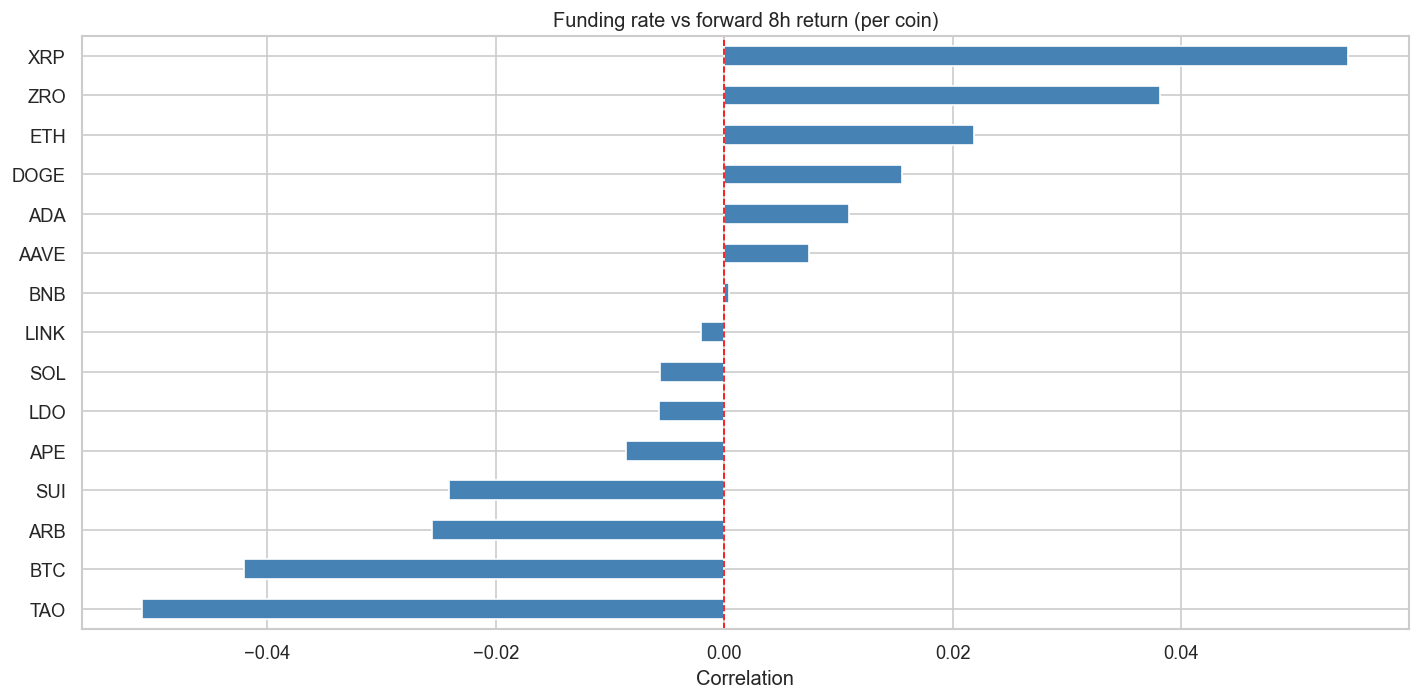

Median corr(funding, fwd_return): -0.002
Note: near zero is good — funding should not predict price direction for a market-neutral strategy


In [134]:
returns = prices.pct_change().shift(-1)

fwd_corr = pd.Series({
    coin: funding[coin].corr(returns[coin]) for coin in funding.columns
})

fig, ax = plt.subplots(figsize=(12, 6))
fwd_corr.sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(0, color='red', lw=1, ls='--')
ax.set_xlabel('Correlation')
ax.set_title('Funding rate vs forward 8h return (per coin)')
plt.tight_layout()
plt.show()

print(f'Median corr(funding, fwd_return): {fwd_corr.median():.3f}')
print('Note: near zero is good \u2014 funding should not predict price direction for a market-neutral strategy')

## 7. Correlation Heatmap

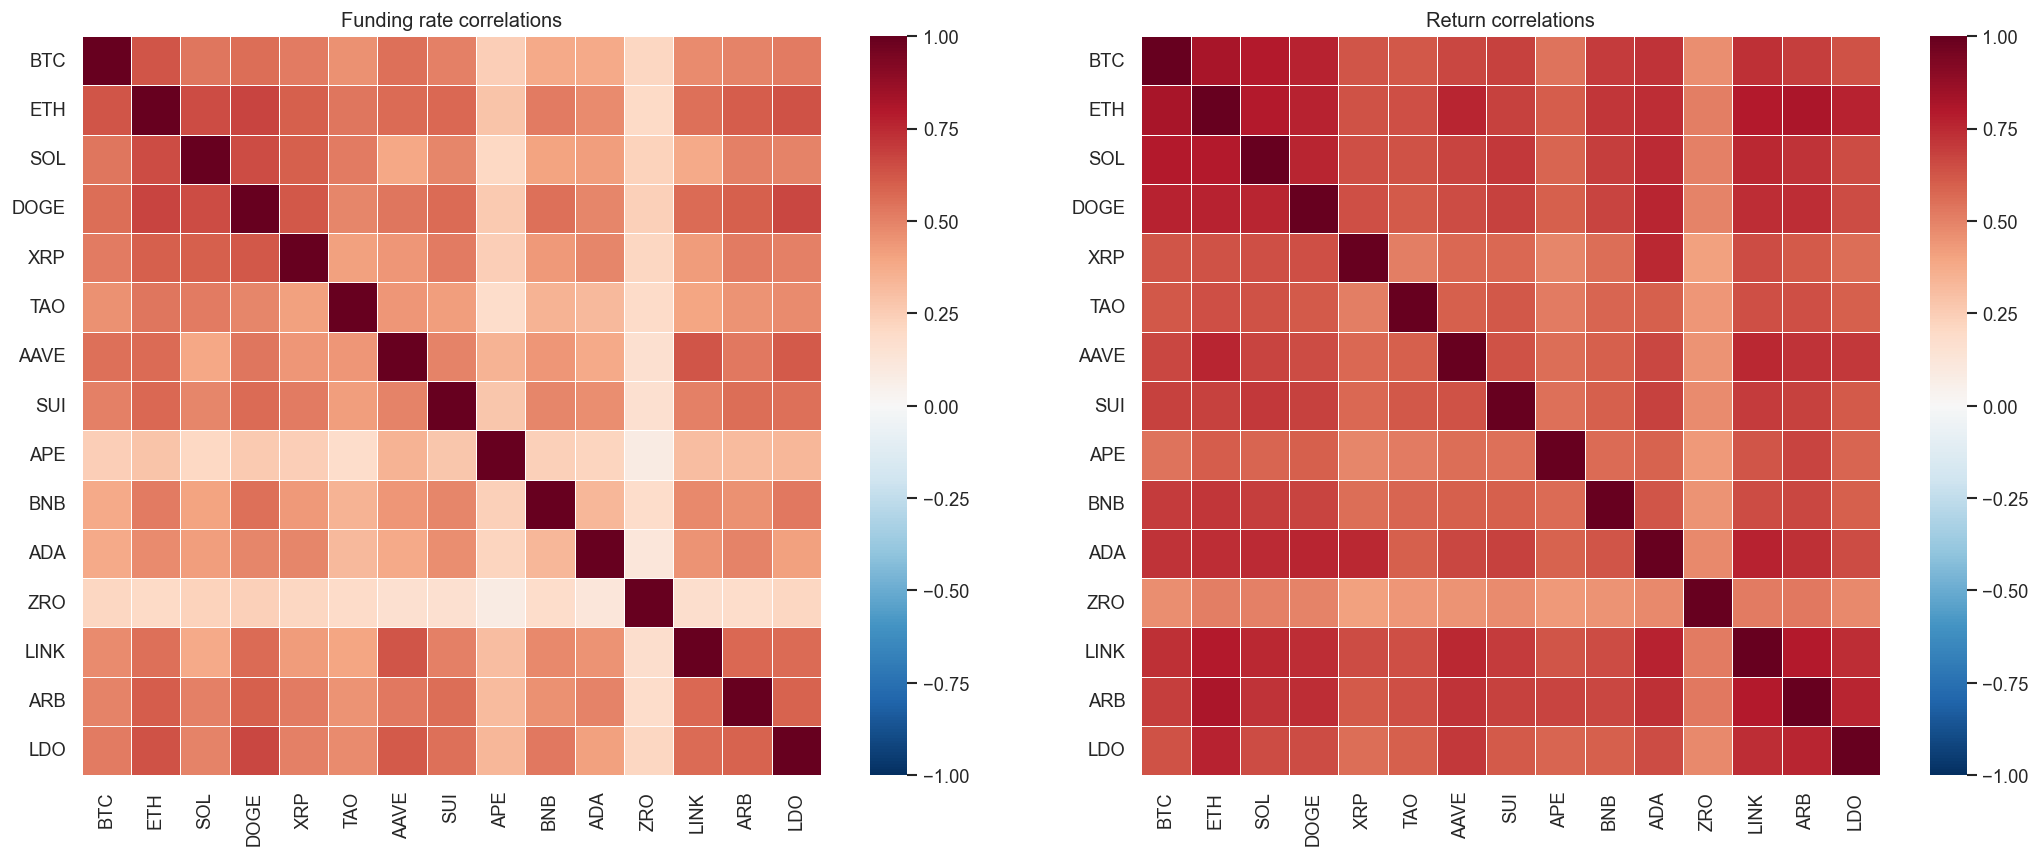

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(funding.corr(), ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.3)
axes[0].set_title('Funding rate correlations')

ret = prices.pct_change().dropna()
sns.heatmap(ret.corr(), ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.3)
axes[1].set_title('Return correlations')

plt.tight_layout()
plt.show()